<a href="https://colab.research.google.com/github/rmhanna/Randa/blob/main/PCA_Projection_of_Distributions_A%2C_B%2C_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

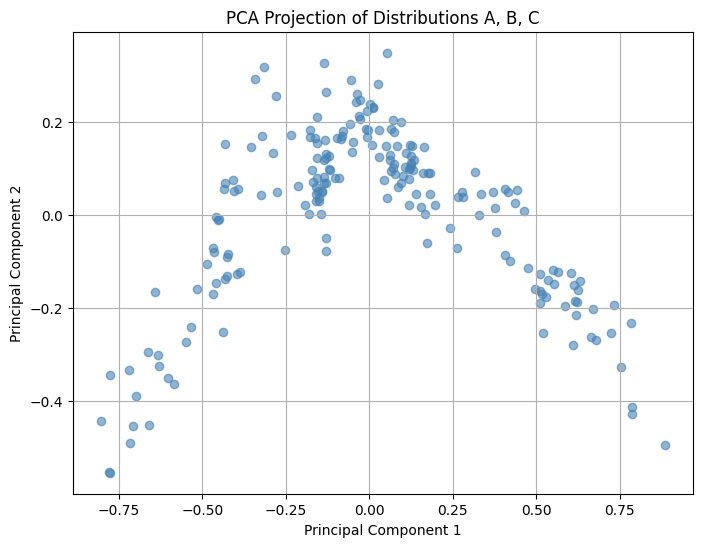

In [2]:
# Box plots help us visualize behavioral data by showing patterns, variability, and outliers across groups.



# When paired with PCA, they reveal how complex traits or responses can be simplified into key dimensions.



# Distribution C suggests more consistent behavior, while A reflects greater diversity, a clue to underlying factors.



# Together, these tools offer a clearer lens into how human behavior clusters and diverges across populations.



# Ex: Pairing PCA with distributions A, B, and C



import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# Set random seed for reproducibility
np.random.seed(42)


# Generate synthetic data based on five-number summaries
def generate_data(min_val, q1, median, q3, max_val, size=200):
    # Simulate data using percentiles and normal distributions around quartiles
    lower = np.random.normal(loc=(min_val + q1)/2, scale=(q1 - min_val)/2, size=size//4)
    mid_lower = np.random.normal(loc=(q1 + median)/2, scale=(median - q1)/2, size=size//4)
    mid_upper = np.random.normal(loc=(median + q3)/2, scale=(q3 - median)/2, size=size//4)
    upper = np.random.normal(loc=(q3 + max_val)/2, scale=(max_val - q3)/2, size=size//4)
    return np.concatenate([lower, mid_lower, mid_upper, upper])


# Distributions A, B, C
A = generate_data(0.00, 0.02, 0.11, 0.32, 0.86)
B = generate_data(0.11, 0.37, 0.48, 0.58, 0.93)
C = generate_data(0.14, 0.69, 0.88, 0.95, 1.00)


# Stack into matrix for PCA
X = np.vstack([A, B, C]).T  # shape (200, 3)


# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


# Plot PCA result
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='steelblue', alpha=0.6)
plt.title('PCA Projection of Distributions A, B, C')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()